# <font color=#F90499>**Modelo Hackathonnn**</font>
***

## <font color=#05C0F3>**Introduccion al problema**</font>

### **Sector del negocio**

Atención al cliente / Marketing / Operaciones — empresas que recopilan opiniones de clientes (reseñas, comentarios en redes sociales, encuestas de satisfacción) y quieren entender rápidamente si el sentimiento es positivo, neutro o negativo.
***

### **Descripción del proyecto**

Crear una API simple que recibe textos (comentarios, reseñas o tweets), aplica un modelo de Data Science para clasificar el sentimiento (Atrasado / Puntual → en este caso: Positivo / Neutro / Negativo o binario Positivo / Negativo) y devuelve el resultado en formato JSON, permitiendo que las aplicaciones consuman esta predicción automáticamente.
***

### **Necesidad del cliente (explicación no técnica)**

Un cliente (empresa) recibe muchos comentarios y no puede leerlos todos manualmente. Quiere:

1. saber rápidamente si los clientes se están quejando o elogiando;

2. priorizar respuestas a comentarios negativos;

3. medir la satisfacción a lo largo del tiempo.

Este proyecto ofrece una solución automática para clasificar mensajes y generar información accionable.
***

### **Validación de mercado**

Analizar si el sentimiento es útil para:

- acelerar la atención al cliente (identificar urgencias);

- monitorear campañas de marketing;

- comparar la imagen de la marca a lo largo del tiempo.

Incluso una solución simple (modelo básico) tiene valor: las pequeñas y medianas empresas utilizan herramientas similares para entender los feedbacks sin un equipo dedicado.
***

### **Expectativa para este hackathon**

**Público:** estudiantes sin experiencia profesional en el área de tecnología, que estudiaron Back-end (Java, Spring, REST, persistencia) y Data Science (Python, Pandas, scikit-learn, notebooks).

**Objetivo:** entregar un MVP funcional que demuestre la integración entre DS y Back-end: un notebook con el modelo + una API que carga ese modelo y responde a las peticiones.

**Alcance recomendado:** clasificación binaria (Positivo / Negativo) o ternaria (Positivo / Neutro / Negativo) con un modelo simple — por ejemplo, usar TF-IDF (una técnica que transforma el texto en números, mostrando qué palabras son más importantes) junto con Regresión Logística (un modelo de aprendizaje automático que aprende a diferenciar sentimientos).
***

### **Entregables deseados**

Notebook (Jupyter/Colab) del equipo de Data Science que contenga:

1. Exploración y limpieza de los datos (EDA);

2. Transformación de los textos en números con TF-IDF;

3. Entrenamiento de modelo supervisado (ej.: Logistic Regression, Naive Bayes);

4. Métricas de desempeño (Accuracy, Precision, Recall, F1-score);

5. Serialización del modelo (joblib/pickle).
***

### **Documentación mínima (README):**

- Cómo ejecutar el modelo.

- Dependencias y versiones de las herramientas.

- Demonstración funcional (Presentación corta).

- Explicar cómo el modelo llega a la predicción.
***

### **Funcionalidades exigidas (MVP)**

1. El servicio debe exponer un endpoint que devuelve la clasificación del sentimiento y la probabilidad asociada a esa clasificación. Ejemplo: POST /sentiment — acepta JSON con campo text y devuelve: `{ "prevision": "Positivo", "probabilidad": 0.87 }`

2. Modelo entrenado y cargable: el back-end debe poder usar el modelo (cargando archivo) o hacer una petición a un microservicio DS que implemente la predicción.

3. Validación de input: verificar si text existe y tiene longitud mínima; devolver error amigable en caso contrario.

4. Respuesta clara: label (+ probabilidad en 0–1) y mensaje de error cuando sea aplicable.

5. Ejemplos de uso: Postman/cURL con 3 ejemplos reales (positivo, neutro, negativo).

6. README explicando cómo ejecutar (pasos simples) y cómo probar el endpoint.
***

### **Equipo de Data Science**

- Cada equipo debe elegir o armar su propio conjunto de datos de comentarios, reseñas o publicaciones que puedan utilizarse para el análisis de sentimientos (ej.: reviews públicos, tweets, evaluaciones de productos, etc.).

- usar Python, Pandas para leer/limpiar datos;

- crear un modelo simple (TF-IDF + LogisticRegression de scikit-learn);

- guardar el pipeline y el modelo con joblib.dump.

- Poner todo en un notebook bien comentado.
***

### **Contrato de integración (definido entre DS y BE)**


Recomendamos definir desde el principio el formato JSON de entrada y salida. Sigue un ejemplo:

{"text": "..."} →

{

"prevision":"Positivo",

"probabilidad":0.9

}
***

## <font color=#05C0F3>**Librerias**</font>

In [1]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=f84c18988478b22317c8ca1975454a008ecc2151f4e821a0a3e2baa865c27bf4
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [2]:
import pandas as pd
# pd.set_option('display.max_colwidth', None)

import numpy as np

# Graficos
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Separador de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluacion de metricas
from sklearn.metrics import classification_report

# Matriz de confusión
from sklearn.metrics import confusion_matrix

# Pipeline de prediccion
from sklearn.pipeline import Pipeline

# Serializacion
import joblib

#Detectar idiomas
from langdetect import detect

#Mezclar aleatoriamente
from sklearn.utils import shuffle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
stops = set(stopwords.words('spanish'))
print(stops)

{'será', 'otras', 'tengáis', 'habíamos', 'estábamos', 'tendríais', 'hayas', 'del', 'éramos', 'se', 'tuviera', 'sentidos', 'hubiese', 'sintiendo', 'tuve', 'habidos', 'suyos', 'estuvieran', 'sentidas', 'estuve', 'todos', 'las', 'fuera', 'fueran', 'estaría', 'vuestro', 'tuvo', 'esté', 'nuestros', 'uno', 'nada', 'estaba', 'tendríamos', 'habrás', 'algo', 'tengamos', 'esas', 'estarías', 'tendré', 'hubimos', 'estarás', 'he', 'tenéis', 'estuvieses', 'al', 'te', 'ella', 'mí', 'haya', 'tuya', 'la', 'tuvisteis', 'sí', 'contra', 'tiene', 'me', 'esos', 'hubiéramos', 'somos', 'otro', 'habremos', 'tuviéramos', 'seréis', 'hayan', 'serías', 'hubieras', 'hubieseis', 'fuimos', 'e', 'fuesen', 'tendrá', 'mi', 'estén', 'durante', 'como', 'hubiésemos', 'está', 'suyo', 'estaban', 'vosotras', 'los', 'estuviesen', 'hube', 'habrá', 'de', 'serán', 'seamos', 'seríais', 'habrán', 'estad', 'tuyas', 'mío', 'nuestro', 'es', 'más', 'habíais', 'tuviésemos', 'habidas', 'a', 'quienes', 'estemos', 'estoy', 'había', 'para',

***

## <font color=#05C0F3>**Datos de comentarios de peliculas en IMDB**</font>

In [4]:
url = "https://media.githubusercontent.com/media/JhonatanO24/sentiment-api-equipo39/refs/heads/data-science/data_science/datasets/IMDB%20Dataset%20SPANISH.csv"
datos = pd.read_csv(url)

In [5]:
datos = datos[['review_es', 'sentimiento']]

In [6]:
display(datos)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo


***

## <font color=#05C0F3>**Analisis exploratorio de datos**</font>
***

### **Muestreo Aleatorio**

In [7]:
datos.head(10)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
5,Probablemente mi película favorita de todos lo...,positivo
6,Seguro que me gustaría ver una resurrección de...,positivo
7,"Este espectáculo fue una idea increíble, fresc...",negativo
8,Alentados por los comentarios positivos sobre ...,negativo
9,"Si te gusta la risa original desgarradora, te ...",positivo


In [8]:
datos.tail(10)

,review_es,sentimiento
49990,"Cojo, cojo, cojo !!!Un festival de 90 minutos ...",negativo
49991,"Les Visiteurs, la primera película sobre los v...",negativo
49992,John Garfield interpreta a un marine que está ...,positivo
49993,Robert Colomb tiene dos trabajos a tiempo comp...,negativo
49994,Esta es tu comedia de chatarra típica. Casi no...,negativo
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo
49999,Nadie espera que las películas de Star Trek se...,negativo


In [9]:
datos.sample(10)

,review_es,sentimiento
19265,"Acabo de llegar a casa de ver ""Radio"".No he vi...",positivo
14352,"Esto es un poco un poco para mí, la primera ve...",negativo
3724,Michelle Rodriguez es la actriz definitoria qu...,positivo
39777,El director Samuel Fuller coincide con una con...,positivo
21384,Un grupo de guardabosques forestales y científ...,negativo
25438,... Así que algunas personas pueden argumentar...,negativo
15508,"""El cine está muerto, ¡vive mucho tiempo el ci...",positivo
43390,"Como usar una camisa de pelo. Positivamente, a...",negativo
12208,"Me refiero a eso de una buena manera, créeme.F...",positivo
733,Así es como Burt Reynolds describe esta pelícu...,positivo


### **Verificación de Dimensiones y Tipos**

In [10]:
print(f'Los datos tienen {datos.shape[0]} filas y {datos.shape[1]} columnas.')

Los datos tienen 50000 filas y 2 columnas.


In [11]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_es    50000 non-null  object
 1   sentimiento  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### **Eliminando duplicados**

In [12]:
datos.shape

(50000, 2)

In [13]:
datos = datos.drop_duplicates()

In [14]:
datos.shape

(49599, 2)

Se eliminan 401 duplicados

### **Longitud de los textos**

In [15]:
datos.describe()

,review_es,sentimiento
count,49599,49599
unique,49599,2
top,Nadie espera que las películas de Star Trek se...,positivo
freq,1,24886


In [16]:
datos['review_es'].describe()

,review_es
count,49599
unique,49599
top,Nadie espera que las películas de Star Trek se...
freq,1


In [17]:
datos['n_palabras'] = datos['review_es'].str.split().str.len() # Separa todas las palabras del comentario y las cuenta
datos['n_palabras']

,n_palabras
0,345
1,161
2,173
3,137
4,237
...,...
49995,170
49996,105
49997,246
49998,232


In [18]:
datos['n_palabras'].describe()

,n_palabras
count,49599.000000
mean,237.436884
std,179.696966
min,6.000000
25%,124.000000
50%,173.000000
75%,293.000000
max,2450.000000


#### Longitud extrema: análisis más profundo de outliers

In [19]:
datos['n_palabras'].quantile([0.90, 0.95, 0.99])

,n_palabras
0.90,474.0
0.95,623.0
0.99,913.0


In [20]:
pd.set_option('display.max_colwidth', None)

In [21]:
datos.loc[datos['n_palabras'] > 1000, 'review_es'].sample(1)

27326    Berlin-born in 1942 Margarethe von Trotta was an actress and now she is a very important director and writer She has been described, perhaps even unfairly caricatured, as a director whose commitment to bringing a woman's sensibility to the screen outweighs her artistic strengths "Rosenstrasse," which has garnered mixed and even strange reviews (the New York Times article was one of the most negatively aggressive reviews I've ever read in that paper) is not a perfect film It is a fine movie and a testament to a rare coalescing of successful opposition to the genocidal Nazi regime by, of all peoples, generically powerless Germans demonstrating in a Berlin streetCo-writer von Trotta uses the actual Rosenstrasse incident in the context of a young woman's search for information about her mother's never disclosed life as a child in the German capital during World War IIThe husband of Ruth Weinstein (Jutta Lampe) has died and in a surprising reversion to an orthodox Jewish lifestyle apparently hitherto in long abeyance, Ruth not only "sits shivah" (the Jews' week-long mourning ritual) but she insists on following the strict proscriptions of her faith Her apartment in New York City reflects the affluence secured by her deceased spouse's labors Her American-born daughter, Hannah (Maria Schrader) and her brother are a bit put-off by mom's assumption of restrictive orthodox Jewish practices but they pitch in The mother coldly rejects the presence of Hannah's fiance, a non-Jew named Luis (Fedja van Huet) A domestic crisis might well erupt as Ruth warns that she'll disown Hannah if she doesn't give up doting, handsome Luis Stay tunedA cousin arrives to pay her respects and also drops clues to an interested Hannah about a wartime mystery about mom's childhood in Berlin Hannah is intrigued - she queries her mom who resolutely refuses to discuss that part of her life This is very, very realistic I grew up with parents who fled Nazi Germany just in time and I knew many children whose families, in whole but usually in part, escaped the Holocaust Those days were simply not discussedSo Hannah, having learned that a German gentile woman saved Ruth's life, traipses off to Berlin hoping to find the savior still breathing Were she not, this would have been a very short film But Ruth, pretending to be a historian, locates 90 year-old Lena Fischer (Doris Schade), now a widow As the happy-to-be-interviewed but shaken up by repressed memories Lena tells her story, the scenes shift fairly seamlessly between present day Berlin and the war-time capitalThe young Lena of 1943 (Katja Riemann) was a fine pianist married to a Jewish violinist, Fabian Fischer (Martin Feifel) With the advent of the Nazi regime he was required to use "Israel" as a middle name just as Jewish women had to add "Sarah" to their names(incidentally I wish IMDb had not given Fabian's name on its characters list with the false "Israel" included-it simply perpetuates a name applied by Nazis as a mark of classification and degradation)While Germany deported most of its Jewish population to concentration camps, those married to "Aryans" were exempted For a time Until 1943 when the regime decided to take them too (most were men; a minority were Jewish women married to non-Jews) The roundup is shown here in all its frightening intensityThe young Lena tries to locate her husband All she and many other women know is that they're confined in a building on Rosenstrasse The crowd of anxious women builds up, some piteously seeking help from German officers who predictably refuse aid and also verbally abuse them ("Jew-loving whore" being one appellation) As a subplot Lena more or less adopts eight-year-old Ruth who hid when her mother was seized (remember, Ruth is now sitting shiva in Manhattan) The child Ruth is fetchingly portrayed by Svea Lohde Through increasingly angry protestations the women finally prevail The men, and a handful of women, are released As in the real story the Nazis gav

In [22]:
datos[['review_es', 'n_palabras']].query('n_palabras > 500').sample(10)

review_es  \
45142                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            El hombre, es este pésimo. No se merece mucho en el sentido del comentario, por lo que, mantenerlo breve, Rebecca Demornay es un psiquiatra policial altamente disciplinado que cae para el amante de la latina Antonio Banderas en una tienda de vinos, él de la cola de caballo y las cárceles. Cuando ella corta suelta, ella realmente corta suelta. Aparte de este asunto tórrido que está teniendo (y debemos admitir que el asunto tiene sus protuberancias de velocidad) es un pez bastante frío. Su roto, el padre enfermizo se presenta por primera vez en años y lo apaga. Ella también es experta en mantener su vecino de arriba de la planta superior (Dennis Miller) a la bahía. Y hay prisionero Harry Dean Stanton, quien está tratando de maniobrarla para que le diera un diagnóstico de trastorno de la personalidad múltiple para que no tenga sus privados clavados en la pared para los asesinatos en serie que está comprometido. Todas estas personas, y quizás más, se sospechan de inmediato. Cuando las cosas extrañas comienzan a pasarla. Alguien envía sus flores muertas. Alguien hace cosas indescriptibles para su gato de mascotas. (La próxima vez que vea que una mascota doméstica aparezca en una parcela o se teje en el armario o se hierve en una olla, voy a voy a vomitar.) Entonces, ¿quién lo está haciendo? Suponer. Ningún poder en la Tierra podría obligarme a revelar el final, pero tal vez una sugerencia ayudará a: abuso de la infancia. La excusa de abuso es un negocio interesante en sí mismo, mucho más interesante que la película. ¿Qué significa "abuso de la infancia"? ¿Nos referimos a abuso sexual? ¿Físico? ¿Ambas cosas? ¿Qué hay de golpear a un niño sobre la espalda con una cuchara de cocción de madera, lo suficientemente fuerte como para romperlo? Eso es lo que me pasó a mí y a mi hermano cuando éramos niños, así como las cosas similares les ocurrieron a todos los otros niños errantes en el vecindario. Abuso sexual? Eso nunca le sucedió a ninguno de nosotros, por lo que yo sepa, aunque no estoy seguro de que hubiera sido rechazado con cualquier grado de animación. En el pueblo de Samoan, estudié durante dos años, había un caso de un niño adolescente encontrado jugando sexualmente con una niña mucho más joven. La familia de la niña le sacó el infierno de él. La propia familia del niño lo envió a vivir con otra rama de la familia en otro pueblo, un exilio que duró dos años. En el momento en que regresó el inci

In [23]:
pd.set_option('display.max_colwidth', 50)

### **Verificar la distribución de la columna objetivo (Sentimiento)**

In [24]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,24886
negativo,24713


In [25]:
datos['sentimiento'].value_counts(normalize=True)

,proportion
sentimiento,
positivo,0.501744
negativo,0.498256


In [26]:
datos.sample(10)

,review_es,sentimiento,n_palabras
36787,Me gustaría comentar sobre cómo se eligen las ...,negativo,109
19989,Excelentes efectos especiales hacen que este d...,positivo,146
45354,Encuentro 700 clubes de vez en cuando y solo e...,negativo,170
1895,"Esto se asignó a los fanáticos, ya que el ""gan...",negativo,444
46010,Eisenstein no era solo uno de los mejores y so...,positivo,129
40501,Le di a esta película 2 estrellas solo porque ...,negativo,140
29830,El hombre contaminado es una buena película qu...,positivo,141
42153,El problema es que la película entró en los as...,positivo,391
1004,"De manera extraña, esta película nunca llegó a...",positivo,113
3359,Crecí en el sur de West Virginia;Tengo aproxim...,positivo,163


### **Graficos**

In [27]:
sns.axes_style()

{'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': '.8',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [28]:
sns.set_theme(
    style="darkgrid",
    font_scale=1.1
)

### Colores

In [29]:
color_primario = "#05C0F3"
color_secundario = "#F90499"

#### Histograma

¿Cómo es la distribución del tamaño de los textos (reviews) que usaremos para entrenar el modelo de sentimiento?

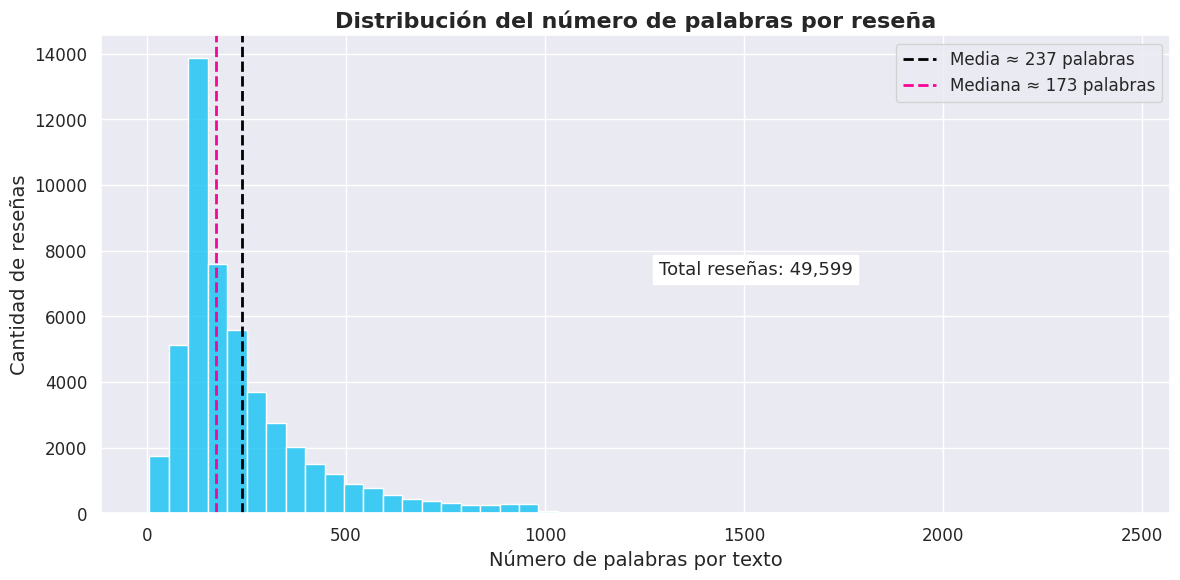

In [30]:
def distribucion_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.histplot(
      datos['n_palabras'],
      bins = 50,
      color = color_primario
      )

  plt.title(
      "Distribución del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  plt.ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  plt.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  plt.text(
      0.50 * plt.xlim()[1],
      0.50 * plt.ylim()[1],
      f"Total reseñas: {len(datos):,}",
      fontsize=13,
      bbox=dict(facecolor="white")
  )

  plt.legend() # Muestra la leyenda
  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña()

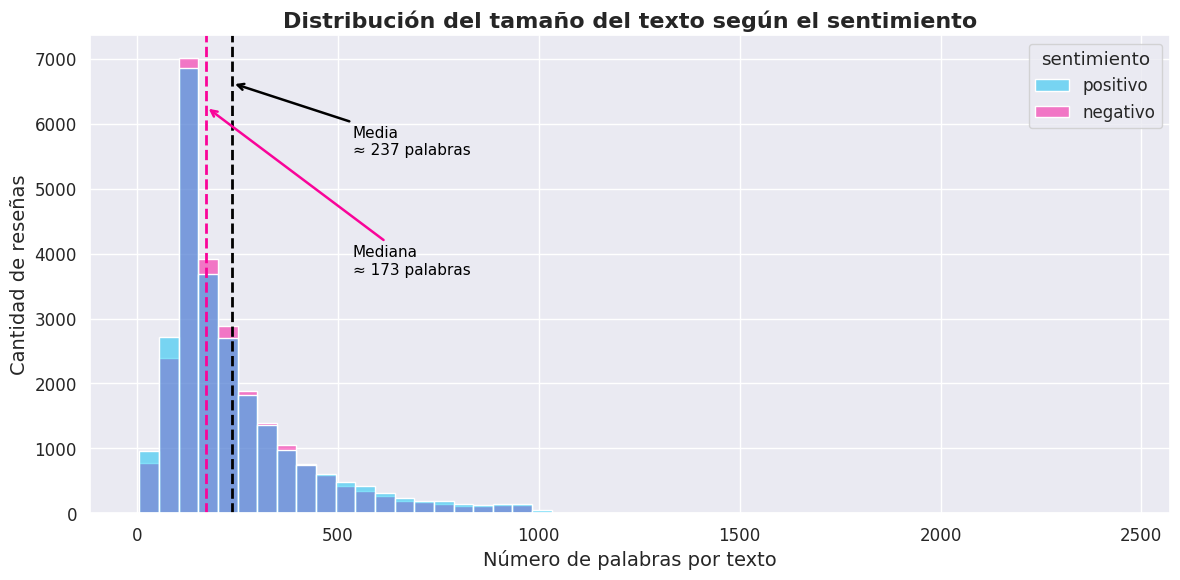

In [31]:
def distribucion_numero_palabras_por_reseña_por_sentimiento():
  fig, ax = plt.subplots(figsize=(12,6))

  sns.histplot(
      data = datos,
      x = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario],
      bins=50
  )

  ax.set_title(
      "Distribución del tamaño del texto según el sentimiento",
      fontsize = 16,
      fontweight = "bold"
  )

  ax.set_xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  ax.set_ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  ax.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  ax.axvline(
      mediana,
      color = color_secundario,
      linestyle = "--",
      linewidth = 2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  ax.annotate(
      f"Media\n≈ {media:.0f} palabras",
      xy = (media, ax.get_ylim()[1] * 0.9),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.75),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'black',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  texto_moda = ('Mediana')
  ax.annotate(
      f"Mediana\n≈ {mediana:.0f} palabras",
        xy = (mediana, ax.get_ylim()[1] * 0.85),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.50),
      arrowprops = dict(
            arrowstyle = "->",
            color = color_secundario,
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña_por_sentimiento()

#### Boxplot

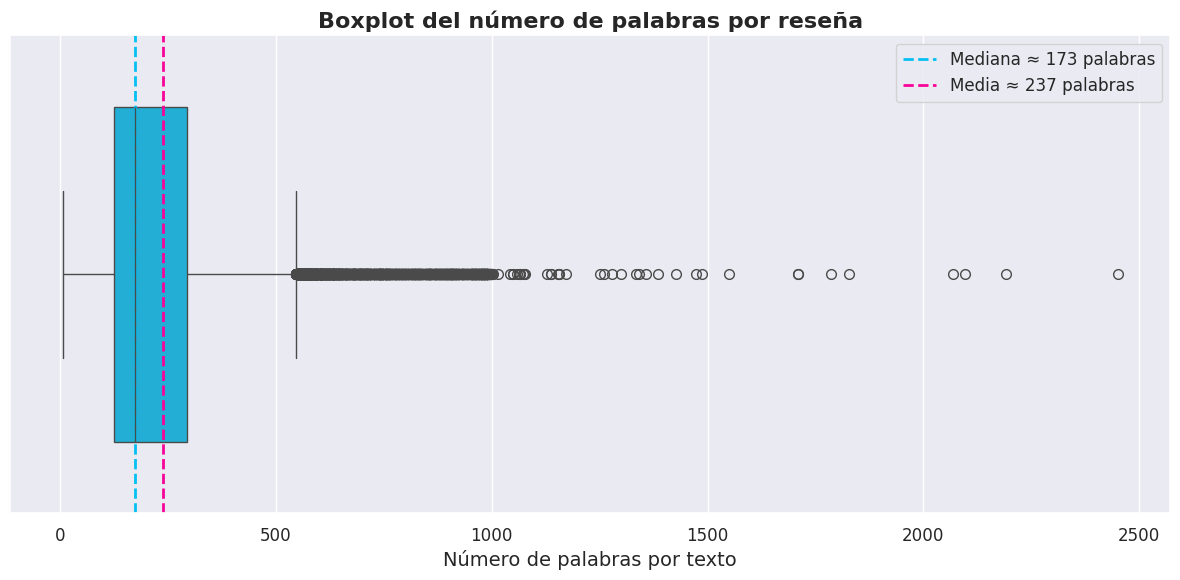

In [32]:
def boxplot_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.boxplot(
      x = datos['n_palabras'],
      color = color_primario,
      width = 0.7, # Tamaño del boxplot
      fliersize = 7, # Tamaño de los puntos atípicos
  )

  plt.title(
      "Boxplot del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_primario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )
  # Línea de referencia: media
  media = datos['n_palabras'].mean()
  plt.axvline(
      media,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Media ≈ {media:.0f} palabras"
  )


  plt.legend()
  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña()

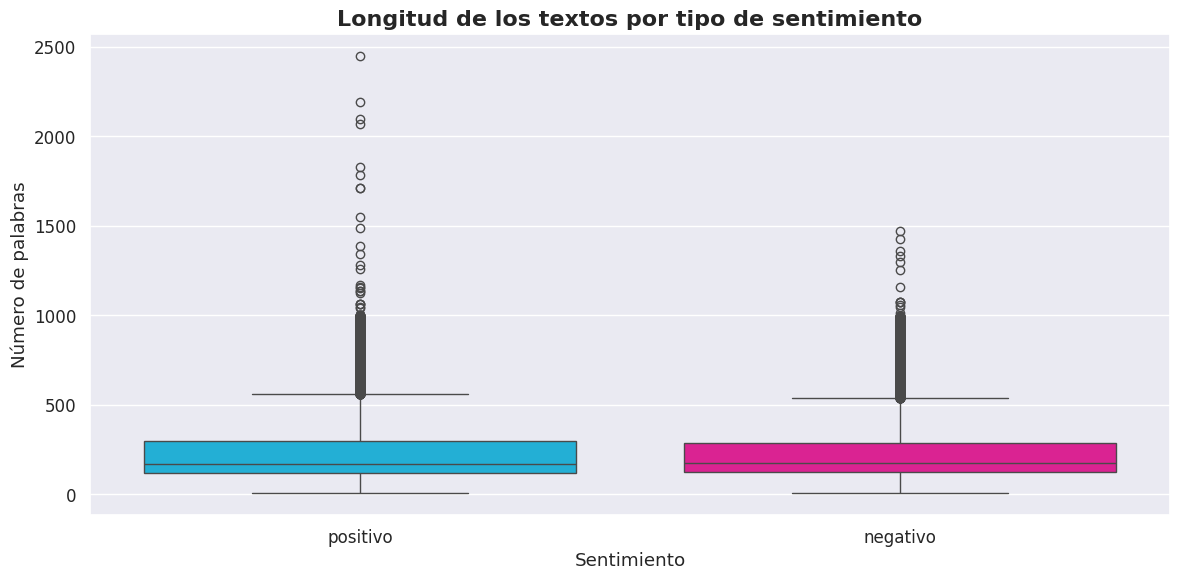

In [33]:
def boxplot_numero_palabras_por_reseña_por_sentimiento():
  plt.figure(figsize=(12,6))

  sns.boxplot(
      data = datos,
      x='sentimiento',
      y = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario]
  )

  plt.title(
      "Longitud de los textos por tipo de sentimiento",
      fontsize=16,
      fontweight="bold"
      )

  plt.xlabel("Sentimiento")

  plt.ylabel("Número de palabras")

  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña_por_sentimiento()

### **Conclusion**

#### **Conclusiones sobre la calidad de los datos**

* El conjunto de datos presenta algunos registros duplicados pero pocos comparados a la cantidad de datos, lo que indica una buena calidad inicial, además de que con la limpieza se eliminan para evitar sesgos por repetición de observaciones durante el entrenamiento del modelo.

* Las columnas cuentan con tipos de datos adecuados para el análisis, permitiendo trabajar correctamente con texto y variables categóricas.

#### **Conclusiones sobre la longitud de los textos**

- La longitud de las reseñas presenta alta variabilidad, con una media aproximada de 237 palabras y valores extremos que alcanzan más de 2400 palabras.

- La diferencia entre media y mediana indica una distribución sesgada a la derecha, confirmada por la presencia de múltiples outliers visibles en el boxplot.

- La mayoría de los textos se concentra en rangos bajos y medios de longitud, mientras que un pequeño porcentaje de reseñas muy extensas genera una cola larga en la distribución.

#### **Conclusiones sobre el idioma de los datos**

- Se detectó la presencia de reseñas en más de un idioma (español e inglés) dentro de la columna utilizada para el entrenamiento.

- Esto introduce un posible ruido lingüístico, ya que TF-IDF tratará palabras de ambos idiomas como parte del mismo vocabulario.

#### **Conclusión general del EDA**

El análisis exploratorio confirma que el conjunto de datos es apto para entrenar un modelo de análisis de sentimiento, cumpliendo con los requisitos del MVP propuesto.

Si bien existen desafíos como la alta variabilidad en la longitud de los textos y la presencia de múltiples idiomas, estos no impiden la construcción de un modelo inicial basado en TF-IDF y regresión logística.

El EDA permite identificar claramente oportunidades de mejora que pueden abordarse en iteraciones futuras, alineándose con el enfoque incremental esperado.

## <font color=#05C0F3>**Limpieza de datos**</font>

### **Tratamiento de Valores Nulos e Inconsistencias**

#### Conteo de valores nulos

In [34]:
datos.isnull().sum()

,0
review_es,0
sentimiento,0
n_palabras,0


No hay valores nulos en ninguna columna

### **Limpieza y Normalización del Texto**

#### Eliminar reseñas en inglés

In [35]:
def detectar_idioma(texto):
    try:
        return detect(texto) #Se usa la biblioteca langdetect
    except:
        return "desconocido"

In [36]:
datos.shape

(49599, 3)

In [37]:
#Columna con el idioma de la reseña (El procesamiento tardará)
datos['idioma_detectado'] = datos['review_es'].apply(detectar_idioma)

In [38]:
datos_limpios = datos[datos['idioma_detectado'] == 'es'].copy() #Solo guarda los datos en español

In [39]:
filas_originales = len(datos)
filas_limpias = len(datos_limpios)
print(f"Se eliminaron {filas_originales - filas_limpias} filas que no estaban en español")

Se eliminaron 1815 filas que no estaban en español


In [40]:
datos = datos_limpios

In [41]:
datos.shape

(47784, 4)

#### Verificar la distribución de la columna objetivo (Sentimiento)

In [42]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,23935
negativo,23849


In [43]:
print("\nEstadísticas de longitud antes del balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud antes del balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23849.0  227.789090  157.364916   6.0  125.0  172.0  284.0  998.0
positivo     23935.0  230.686693  166.550784  10.0  122.0  170.0  290.0  955.0


#### Eliminar las reseñas más grandes (partes del sesgo) para mantener el equilibrio en el número de reseñas de ambos sentimientos

In [44]:
datos_pos = datos[datos['sentimiento'] == 'positivo'].copy()
datos_neg = datos[datos['sentimiento'] == 'negativo'].copy()

In [45]:
diferencia = len(datos_pos) - len(datos_neg)
print(f"Hay {diferencia} reseñas positivas extras")

Hay 86 reseñas positivas extras


In [46]:
datos_pos_balanceado = datos_pos.sort_values(by='n_palabras', ascending=False).iloc[diferencia:]
len(datos_pos_balanceado)

23849

In [47]:
datos_equilibrados = pd.concat([datos_pos_balanceado, datos_neg])

In [48]:
datos = shuffle(datos_equilibrados, random_state=42).reset_index(drop=True)

In [49]:
datos['sentimiento'].value_counts()

,count
sentimiento,
negativo,23849
positivo,23849


In [50]:
print("\nEstadísticas de longitud tras el balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud tras el balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23849.0  227.789090  157.364916   6.0  125.0  172.0  284.0  998.0
positivo     23849.0  228.243406  161.791663  10.0  121.0  169.0  289.0  883.0


#### Estandarización a minúsculas

In [51]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado
0,Me derrota absolutamente por qué Godard se tom...,negativo,328,es
1,"¿Nunca debo ir a este hospital [o hospicio, si...",positivo,127,es
2,"Alan Rudolph es un director tan así, sin ese t...",negativo,233,es
3,Alquilé esto pensando que sería bastante bueno...,negativo,105,es
4,"La serie Azul Planet es, sin lugar a dudas, un...",positivo,209,es
...,...,...,...,...
47693,Crecí en la ciudad de Nueva York y todas las t...,positivo,179,es
47694,96 minutos de esto es cruel ... y amo a los an...,negativo,407,es
47695,"Oh hombre, ¿esta película alguna vez muerde!Si...",negativo,72,es
47696,"Sin duda, una de las grandes obras maestras de...",positivo,636,es


In [52]:
datos['review_es_limpio'] = datos['review_es'].str.lower()

In [53]:
datos['review_es_limpio']

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,"¿nunca debo ir a este hospital [o hospicio, si..."
2,"alan rudolph es un director tan así, sin ese t..."
3,alquilé esto pensando que sería bastante bueno...
4,"la serie azul planet es, sin lugar a dudas, un..."
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,96 minutos de esto es cruel ... y amo a los an...
47695,"oh hombre, ¿esta película alguna vez muerde!si..."
47696,"sin duda, una de las grandes obras maestras de..."


#### Eliminación de caracteres especiales y números

Se usa regex (expresiones regulares) para remover símbolos, números o puntuación, lo cual es esencial para el procesamiento de texto

In [54]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)


In [55]:
display(datos['review_es_limpio'])

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguo...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


`[^a-záéíóúñü\s]`

Significa:
  Cualquier carácter que NO sea:
  - letras minúsculas
  - letras con tilde
  - ñ, ü
  - espacios

In [56]:
# Reduce repeticiones excesivas de caracteres:
# Ej: "bueeeno" → "bueeno", "holaaaa" → "holaa"
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(
    r'(.)\1{2,}', r'\1\1', regex=True
)

Se decidió normalizar las secuencias de un mismo carácter repetido
3 o más veces, reduciéndolas a un máximo de 2 repeticiones.

Esta decisión permite:
- Reducir la variabilidad innecesaria del vocabulario
- Conservar parte de la intención emocional del texto
- Mejorar la calidad del texto para tareas de NLP como análisis de sentimiento

La normalización de caracteres repetidos se aplica para evitar que variaciones
ortográficas no semánticas afecten la tokenización y el desempeño del modelo.
Se conserva un máximo de dos repeticiones para no eliminar completamente
el énfasis expresivo del lenguaje informal.

#### Eliminar espacios múltiples

In [57]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [58]:
display(datos['review_es_limpio'])

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguos ...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


## <font color=#05C0F3>**Transformación de Características (Feature Engineering)**</font>

In [59]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado,review_es_limpio
0,Me derrota absolutamente por qué Godard se tom...,negativo,328,es,me derrota absolutamente por qué godard se tom...
1,"¿Nunca debo ir a este hospital [o hospicio, si...",positivo,127,es,nunca debo ir a este hospital o hospicio si qu...
2,"Alan Rudolph es un director tan así, sin ese t...",negativo,233,es,alan rudolph es un director tan así sin ese to...
3,Alquilé esto pensando que sería bastante bueno...,negativo,105,es,alquilé esto pensando que sería bastante bueno...
4,"La serie Azul Planet es, sin lugar a dudas, un...",positivo,209,es,la serie azul planet es sin lugar a dudas uno ...
...,...,...,...,...,...
47693,Crecí en la ciudad de Nueva York y todas las t...,positivo,179,es,crecí en la ciudad de nueva york y todas las t...
47694,96 minutos de esto es cruel ... y amo a los an...,negativo,407,es,minutos de esto es cruel y amo a los antiguos ...
47695,"Oh hombre, ¿esta película alguna vez muerde!Si...",negativo,72,es,oh hombre esta película alguna vez muerdesi al...
47696,"Sin duda, una de las grandes obras maestras de...",positivo,636,es,sin duda una de las grandes obras maestras de ...


### **Definición de variables de entrada (X) y salida (y)**

In [60]:
X = datos['review_es_limpio']

In [61]:
display(X)

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguos ...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


In [62]:
y = datos['sentimiento'].map({
    'negativo': 0,
    'positivo': 1
})

In [63]:
display(y)

,sentimiento
0,0
1,1
2,0
3,0
4,1
...,...
47693,1
47694,0
47695,0
47696,1


### **División de datos en conjuntos de entrenamiento y prueba**

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)

### **Inicialización del Vectorizador TF-IDF**

El TF-IDF (Term Frequency-Inverse Document Frequency) es la técnica clave que transforma el texto en números, mostrando qué palabras son más importantes para cada documento/reseña.

In [65]:
stopwords_es = stopwords.words('spanish')

In [66]:
negaciones = {'no', 'ni', 'sin', 'pero', 'nunca', 'jamás'}

In [67]:
stopwords_personalizadas = list(set(stopwords_es) - negaciones)

In [ ]:
vectorizador = TfidfVectorizer(
    stop_words = stopwords_personalizadas,
    ngram_range = (1, 2),
    max_features = 5000,
    strip_accents='unicode',
    min_df = 5,
    max_df = 0.9,
    sublinear_tf = True
)

stop_words=stopwords_personalizadas
Se usan stopwords en español, pero se conservan negaciones como “no”, “pero”, “sin” para no perder información semántica clave en el sentimiento.

- g`ram_range=(1, 2)`
Incluye unigramas y bigramas para capturar tanto palabras individuales como expresiones relevantes (“no me gustó”, “muy buena”).

- `max_features=5000`
Limita el vocabulario a los términos más informativos, logrando un buen balance entre rendimiento y costo computacional.

- `min_df=5`
Elimina términos muy poco frecuentes, reduciendo ruido y aumentando la estabilidad del modelo.

- `max_df=0.9`
Excluye palabras demasiado comunes que no ayudan a diferenciar el sentimiento.

- `sublinear_tf=True`
Reduce el impacto de repeticiones excesivas de una palabra, evitando que dominen la representación del texto.

### **Ajuste (fit) y Transformación (transform) del conjunto de entrenamiento**

In [69]:
X_train_tfidf  = vectorizador.fit_transform(X_train)

In [70]:
display(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2663413 stored elements and shape (33388, 5000)>

### **Transformación del conjunto de prueba**

In [71]:
X_test_tfidf = vectorizador.transform(X_test)

In [72]:
display(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1127657 stored elements and shape (14310, 5000)>

#### Dimension

In [73]:
X_train_tfidf.shape

(33388, 5000)

In [74]:
X_test_tfidf.shape

(14310, 5000)

## <font color=#05C0F3>**Modelado y Evaluación**</font>

El modelo recomendado es la Regresión Logística, una técnica de clasificación supervisada simple y efectiva para este tipo de problemas.

### **Entrenamiento**

#### Inicialización del modelo de clasificación (Regresión Logística)

In [75]:
modelo = LogisticRegression(
    random_state = 42,
    max_iter = 1000,
    class_weight = 'balanced',
    solver = 'liblinear'
    )

Se utiliza Regresión Logística para la clasificación de sentimiento debido a su estabilidad, buen desempeño con texto vectorizado mediante TF-IDF y capacidad de devolver probabilidades, requisito clave para la API.


- `max_iter=1000`
Aumenta el número máximo de iteraciones para asegurar que el modelo tenga suficiente tiempo para converger correctamente, especialmente al trabajar con un gran número de características generadas por TF-IDF.

- `class_weight='balanced'`
Ajusta automáticamente el peso de cada clase, haciendo el modelo más robusto ante posibles desbalances y evitando sesgos en la predicción.

- `solver='liblinear'`
Selecciona un método de optimización estable y eficiente, especialmente adecuado para problemas de clasificación binaria con conjuntos de datos de tamaño medio y alta dimensionalidad.

#### Entrenamiento del modelo

In [76]:
modelo.fit(X_train_tfidf, y_train, )

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

#### Predicciones

In [77]:
y_pred = modelo.predict(X_test_tfidf)

In [78]:
y_proba = modelo.predict_proba(X_test_tfidf)

### **Evaluación del Desempeño**

#### Cálculo y presentación de métricas

In [79]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['negativo', 'positivo']))


Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.88      0.86      0.87      7155
    positivo       0.86      0.88      0.87      7155

    accuracy                           0.87     14310
   macro avg       0.87      0.87      0.87     14310
weighted avg       0.87      0.87      0.87     14310



#### Obtener palabras más significativas para cada sentimiento

In [80]:
palabras = vectorizador.get_feature_names_out()
coefs = modelo.coef_.flatten()
datos_palabras = pd.DataFrame({'palabra': palabras, 'coeficiente': coefs})

In [81]:
top_pos = datos_palabras.nlargest(10, 'coeficiente')
top_neg = datos_palabras.nsmallest(10, 'coeficiente')
top_palabras = pd.concat([top_pos, top_neg])

/tmp/ipython-input-3743336128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')


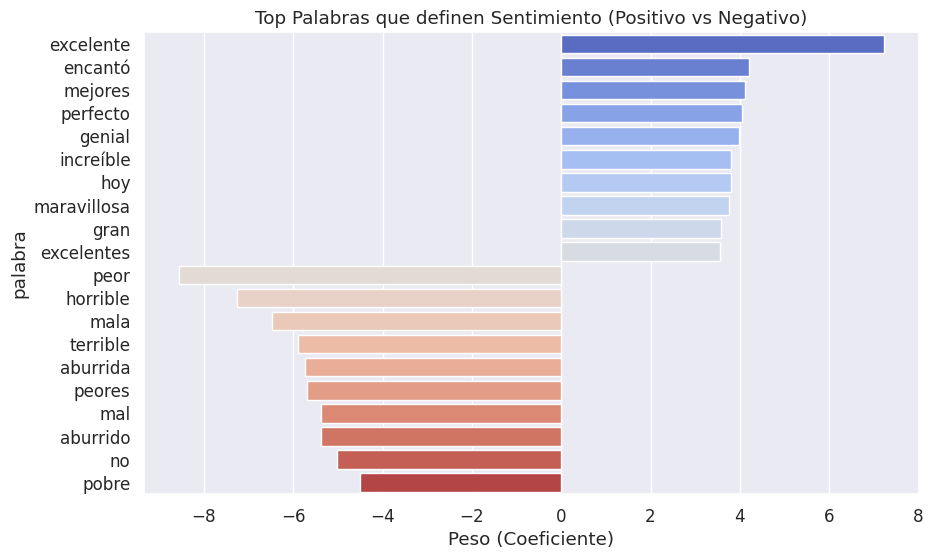

In [82]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')
plt.title('Top Palabras que definen Sentimiento (Positivo vs Negativo)')
plt.xlabel('Peso (Coeficiente)')
plt.show()

#### Análisis de Errores


In [83]:
datos_test = X_test.to_frame(name='review').copy()
datos_test['real'] = y_test
datos_test['prediccion'] = y_pred

In [84]:
errores = datos_test[datos_test['real'] != datos_test['prediccion']]
print(f"Total de errores: {len(errores)} de {len(datos_test)}")

Total de errores: 1849 de 14310


In [85]:
errores.sample(10)

,review,real,prediccion
8428,realmente me gustó esta película no tanto para...,1,0
20175,este es un espagueti muy memorable occidental ...,1,0
38866,al comienzo de la película ramgopal verma dice...,0,1
42015,por lo que puedo decirle a pesar de los coment...,0,1
23021,trabajo en memorial hermann hospital tmc y tam...,0,1
35929,el cuarto hombre paul verhoeven países bajos u...,1,0
42656,desde la primera vez que vi la cubierta de la ...,0,1
23642,otra acción de acción aventura turgida de la f...,0,1
31931,la paz y la belleza de koyaanisqatsi fue una a...,0,1
6092,cinco años después de la guerra civil de los e...,0,1


##### Falsos Positivos (Eran negativos y se clasificaron como positivos)

Son los errores más importantes y que se tienen que destacar, dado que en los requisitos (y en general para cualquier modelo de atención al cliente) es peor ignorar los comentarios negativos y no darles atención (falsos positivos)

In [86]:
for i, row in errores[errores['prediccion'] == 1].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: si el término en sí no era geográfico y semánticamente sin sentido uno podría consultar ned kelly como western australiano para la gente abajo ned kelly estaba aparentemente un bandido de héroe popular similar a robin hood jesse james bonnie y clyde y butch cassidy y el niño sundance el descendiente...
Real: 0 | Pred: 1

Review: alquilé esta película porque esperaba que fuera uno toda la familia disfruteaunque la película es amigable para la familia mi familia no lo disfrutó porque da una visión falsa de diossi obedeces a dios y lo sigue no tienes éxito garantizadotu equipo de fútbol no siempre ganaráno te pondrás mágicamen...
Real: 0 | Pred: 1

Review: soy una gran marca para la música de neil young y con eso y el alabado brillante la película recibió en muchos círculos de prensa altindie golpeó la primera muestra de greendale que pude encontrar mi emoción fue de corta duración ya que esta historia turgida y el débil momento lírico dejó a la mayor...
Real: 0 | Pred: 1



##### Falsos Negativos (Eran positivos y se clasificaron como negativos)

In [87]:
for i, row in errores[errores['prediccion'] == 0].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: tenía años cuando este espectáculo estaba en la televisiónde lejos fue mi favoritolos actores eran muy creíblesalexandra bastedo era simplemente magnífico solo pido el dvd episodiosno tenían superpoderessolo tenían habilidades humanas superiores fuerza audición vistalos actores eran muy buenos en su...
Real: 1 | Pred: 0

Review: se divirtió viendo esta película a pesar de la sensación de que obtuve mucho tiempo que esta película estaba casi copiando a monsters inc hay bastantes cosas que son extremadamente similares entre las dos la relación entre un animal monstruo yun niño pequeño otros animales que intentan romper esa re...
Real: 1 | Pred: 0

Review: este fue uno de los peores episodios de columbo que he visto sin embargo estoy solo en la segunda temporada las actividades típicas de columbo son divertidas e irritantessus cenicientas que le causan problemas se han visto antes y el mío donde siempre se identifica de alguna manera con el asesino en...
Real: 1 | Pred: 0



#### Matriz de confusión


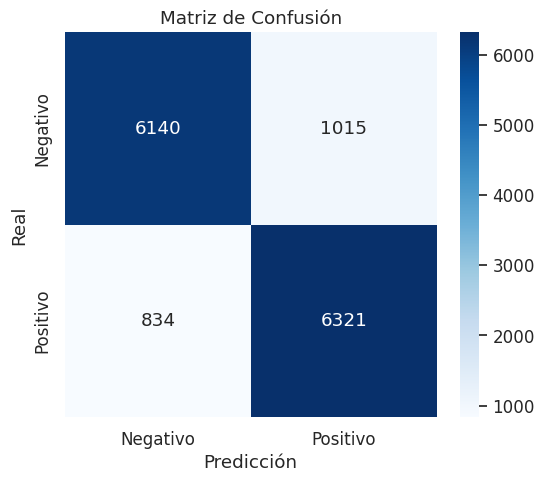

In [88]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')
plt.show()

La matriz de confusión muestra como hay un poco más de falsos positivos que de falsos negativos, para este ejemplo, nos importa mucho más las reseñas negativas para poder atender el disgusto de los clientes. Por lo tanto, es preferible tener menos falsos positivos (reseñas negativas tomadas como positivas) aunque eso conlleve a tener un poco más de falsos negativos.

#### Obtener el mejor umbral para reducir falsos positivos

In [89]:
pipeline_test = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words = stopwords_personalizadas,
        ngram_range = (1, 2),
        max_features = 5000,
        min_df = 5,
        max_df = 0.9,
        sublinear_tf = True
        )),
         ('clf', LogisticRegression(
             random_state = 42,
             max_iter = 1000,
             class_weight = 'balanced',
             solver = 'liblinear'
             ))
         ])

pipeline_test.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2),
                                 stop_words=['será', 'estuvieseis', 'míos',
                                             'porque', 'tendrán', 'sobre',
                                             'cual', 'otras', 'tengáis',
                                             'habida', 'habíamos',
                                             'estuvisteis', 'estábamos',
                                             'tendríais', 'tuvimos', 'hayas',
                                             'estuvieron', 'del', 'estabas',
                                             'seremos', 'en', 'éramos',
                                             'muchos', 'tus', 'seré', 'estuvo',
                                             'se', 'tuviera', 'tanto',
                                             'fuerais', ...],
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])

In [90]:
probs = pipeline_test.predict_proba(X_test)[:, 1]

In [91]:
def probar_umbral(umbral):
    # Si la probabilidad es mayor al umbral, es 'positivo', si no 'negativo'
    preds_ajustadas = np.where(probs > umbral, 1, 0)

    # Generar matriz de confusión con el nuevo umbral
    cm = confusion_matrix(y_test, preds_ajustadas, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return fp, fn, cm

In [92]:
umbrales = [0.5, 0.6, 0.63, 0.64, 0.645, 0.65, 0.655, 0.66, 0.67, 0.7, 0.8]

In [93]:
print(f"{'Umbral':<10} {'Falsos Positivos (Riesgo)':<25} {'Falsos Negativos (Revisión extra)'}")
print("-" * 70)
for u in umbrales:
    fp, fn, _ = probar_umbral(u)
    print(f"{u:<10} {fp:<25} {fn}")

Umbral     Falsos Positivos (Riesgo) Falsos Negativos (Revisión extra)
----------------------------------------------------------------------
0.5        781                       649
0.6        457                       1049
0.63       384                       1203
0.64       356                       1253
0.645      349                       1287
0.65       330                       1321
0.655      321                       1345
0.66       312                       1380
0.67       290                       1448
0.7        230                       1657
0.8        98                        2575


#### Usando el mejor umbral

Al tener un umbral más alto, es más estricto para que el modelo clasifique una reseña como positiva, lo que reduce significativamente la probabilidad de no atender una reseña negativa.

El mejor umbral fue de ***0.65***, con lo que se reducen la cantidad de falsos positivos, pero sin llevar a una enorme cantidad de falsos negativos.
Considerando los requisitos del proyecto, es priorizable detectar correctamente las reseñas negativas que las positivas.

In [94]:
mejor_umbral = 0.65
y_pred_final = np.where(probs > mejor_umbral, 1, 0)


--- Matriz de Confusión con Umbral 0.65 ---


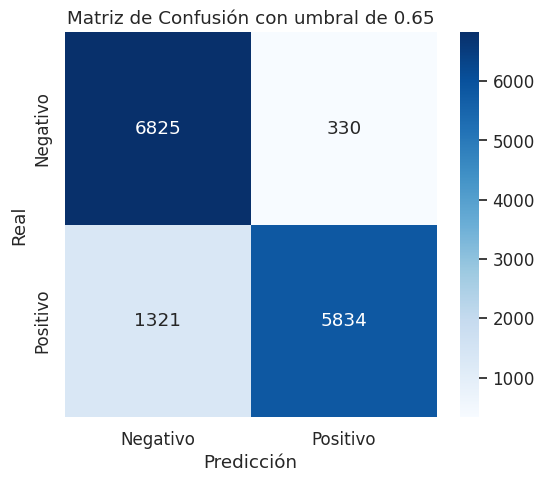

In [95]:
print(f"\n--- Matriz de Confusión con Umbral {mejor_umbral} ---")
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión con umbral de 0.65')
plt.show()

## <font color=#05C0F3>**Serialización e Integración con Back-End (Java)**</font>

Esta es la fase de entrega del artefacto. El modelo entrenado y, crucialmente, el vectorizador TF-IDF (necesario para transformar el texto de entrada que envía el BE), deben ser guardados en un formato binario (joblib o pickle)

### **Definición del Pipeline de Predicción**

Para garantizar que el Back-End pueda hacer predicciones correctas, es mejor serializar el Pipeline completo: Vectorizador + Modelo.

In [ ]:
pipeline_final = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words = stopwords_personalizadas,
        strip_accents='unicode',
        ngram_range = (1, 2),
        max_features = 5000,
        min_df = 5,
        max_df = 0.9,
        sublinear_tf = True
        )),
        ('clf', LogisticRegression(
        random_state = 42,
        max_iter = 1000,
        class_weight = 'balanced',
        solver = 'liblinear'
        ))
    ])

### **Reentrenar el pipeline con X y Y**

In [97]:
pipeline_final.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2),
                                 stop_words=['será', 'estuvieseis', 'míos',
                                             'porque', 'tendrán', 'sobre',
                                             'cual', 'otras', 'tengáis',
                                             'habida', 'habíamos',
                                             'estuvisteis', 'estábamos',
                                             'tendríais', 'tuvimos', 'hayas',
                                             'estuvieron', 'del', 'estabas',
                                             'seremos', 'en', 'éramos',
                                             'muchos', 'tus', 'seré', 'estuvo',
                                             'se', 'tuviera', 'tanto',
                                             'fuerais', ...],
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])

### **Serialización**

In [ ]:
joblib.dump(pipeline_final, 'sentiment_model_1.4.joblib')

['sentiment_model_1.3.joblib']

### **Contrato de Integración y Pruebas Locales**

Prueba en Python para simular la predicción, mostrando cómo el modelo toma un texto sin procesar y genera una predicción con probabilidad.

In [ ]:
# Simulación de predicción
texto_ejemplo = "La interfaz es confusa y me hicieron esperar mucho."

In [ ]:
pred_sentimiento = pipeline_final.predict([texto_ejemplo])

In [ ]:
probabilidades = pipeline_final.predict_proba([texto_ejemplo])

In [ ]:
# Sentimiento y su probabilidad asociada (máxima probabilidad)
max_proba = np.max(probabilidades)

In [ ]:
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

Predicción: [0], Probabilidad: 0.63


#### **FastAPI**

**El siguiente codigo es de prueba y va en el archivo del proyecto en github**

~~~
# Instalaciones
# pip install fastapi uvicorn joblib scikit-learn nltk # Se ejecuta en consola

# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

# Cargar el modelo (UNA SOLA VEZ)
app = FastAPI(title="Sentiment Analysis API")

modelo = joblib.load("sentiment_model_1.1.joblib")

# Contrato de entrada (request)
class SentimentRequest(BaseModel):
    text: str
#    {
#        text: "La película fue excelente"
#    }

# Contrato de salida (response)
class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

# Endpoint principal /sentiment
@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):

    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento"
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

# Ejecutar el servidor
# uvicorn app:app --reload # Se ejecuta en consola

POST http://localhost:8000/sentiment
Content-Type: application/json
# Eso va en:
# Postman
# Swagger
# README
# documentación

# Formato
{
  "text": "La interfaz es confusa y lenta"
}
{
  "prevision": "Negativo",
  "probabilidad": 0.92
}

~~~

**Comentario Fast API (Prueba)** **NO EJECUTAR**

**El archivo de Git tendría que tener esta estrucura**

- Modelo_hackathon.ipynb
- app.py
- requirements.txt
- sentiment_model.joblib

### Archivo requirements.txt
### Dentro del archivo .txt el siguiente texto:

- fastapi
- uvicorn
- joblib
- scikit-learn
- nltk
- numpy

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. cd data_science
- 2. Instalar las librerías (solo la primera vez): pip install -r requirements.txt
- 3. Encender el servidor: uvicorn app:app --reload

### Arhivo ipynb, Modelo_hackathon.ipynb
El archivo .ipynb crea el archivo (sentiment_model.joblib)
Descargar el archivo .joblib y colocarlo dentro de la estructura del Git

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): `pip install -r requirements.txt`
- 2. Encender el servidor: `uvicorn app:app --reload`